In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(23)
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df= pd.DataFrame(class1_sample, columns=['feature1','feature2','feature3'])
df['target'] =1 

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2,cov_mat2,20)

df1 = pd.DataFrame(class2_sample, columns=['feature1','feature2','feature3'])
df1['target'] = 0
df= pd.concat([df,df1],ignore_index=True)

df= df.sample(40)
df.head()


,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [3]:
import plotly.express as px
# y_train_trf =y_train.astype(str)
fig = px.scatter_3d(df,x=df['feature1'], y=df['feature2'], z=df['feature3'],
                    color= df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,line=dict(width=2, color='DarkSlateGray')),
                  selector=dict(mode='markers'))
fig.show()

In [4]:
# Step2: Find Covariance Matrix:
covariance_matrix= np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.34076734 0.24528825 0.10420627]
 [0.24528825 1.12566959 0.23643388]
 [0.10420627 0.23643388 1.327287  ]]


In [5]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
eigen_values

array([1.65691289+0.j, 1.22963722+0.j, 0.90717381+0.j])

In [6]:
eigen_vectors

array([[-0.61002583+0.j, -0.69239396+0.j,  0.3853039 +0.j],
       [-0.53982115+0.j,  0.00718615+0.j, -0.84174906+0.j],
       [-0.58005311+0.j,  0.72148387+0.j,  0.37815264+0.j]])

/home/zaid/.venv/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:3579: ComplexWarning: Casting complex values to real discards the imaginary part
  UVW = np.column_stack(input_args[3:]).astype(float)


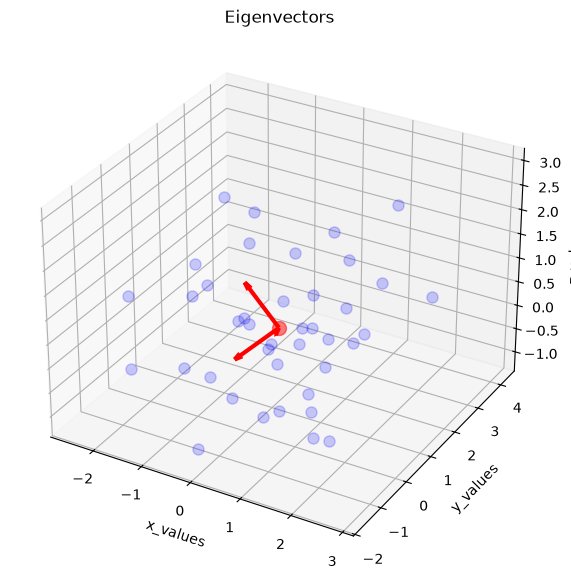

In [12]:

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d

        if renderer is not None:
            xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
            self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        return np.min(zs3d)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)


fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
origin = np.array([
    df['feature1'].mean(),
    df['feature2'].mean(),
    df['feature3'].mean()
])

for v in eigen_vectors.T:
    ax.quiver(
        origin[0], origin[1], origin[2],   # start point
        v[0], v[1], v[2],                  # direction
        color='red',
        linewidth=3,
        arrow_length_ratio=0.15
    )
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()
     

In [13]:
pc = eigen_vectors[0:2]
pc

array([[-0.61002583+0.j, -0.69239396+0.j,  0.3853039 +0.j],
       [-0.53982115+0.j,  0.00718615+0.j, -0.84174906+0.j]])

In [14]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.502355+0.000000j,1.303153+0.000000j,1
1,0.778695+0.000000j,-1.132295+0.000000j,0
2,-0.569075+0.000000j,-0.164066+0.000000j,1
3,-1.083293+0.000000j,-0.494640+0.000000j,1
4,1.660680+0.000000j,0.843708+0.000000j,1


In [18]:
import numpy as np

new_df['PC1'] = np.real(new_df['PC1'])
new_df['PC2'] = np.real(new_df['PC2'])

In [19]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()
     


In [16]:
print(new_df['PC1'].dtype)
print(new_df['PC2'].dtype)

complex128
complex128
